In [5]:
import yfinance as yf
import numpy as np
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install yfinance
from src.risk.monte_carlo_var import monte_carlo_option_var
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# 1. Get latest stock price
stock_hist = ticker.history(period="5d") #check the timeline as well.
S0 = stock_hist["Close"].iloc[-1]

# 2. Get nearest option expiration
exp = ticker.options[0]
chain = ticker.option_chain(exp)

calls = chain.calls
puts = chain.puts

# 3. Pick one option contract
option = calls.iloc[0]

K = option["strike"]

#check these ones. 
option_price = option["lastPrice"]
implied_vol = option["impliedVolatility"]

print("Stock price S0:", S0)
print("Strike K:", K)
print("Option price:", option_price)
print("Implied volatility:", implied_vol)
print("Expiration:", exp)

contracts = 10
portfolio_value = option_price * 100 * contracts
print("Current Option Portfolio Value:", portfolio_value)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python
zsh:1: no such file or directory: /Users/sangpark/Documents/Risk
Stock price S0: 293.32000732421875
Strike K: 230.0
Option price: 46.0
Implied volatility: 3.1845723510742188
Expiration: 2026-05-11
Current Option Portfolio Value: 46000.0


In [7]:
option = calls.iloc[0]
K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=0.5,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="call",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=10
)
print("Monte Carlo Option VaR:", result["var"])

Monte Carlo Option VaR: 18820.7186050494


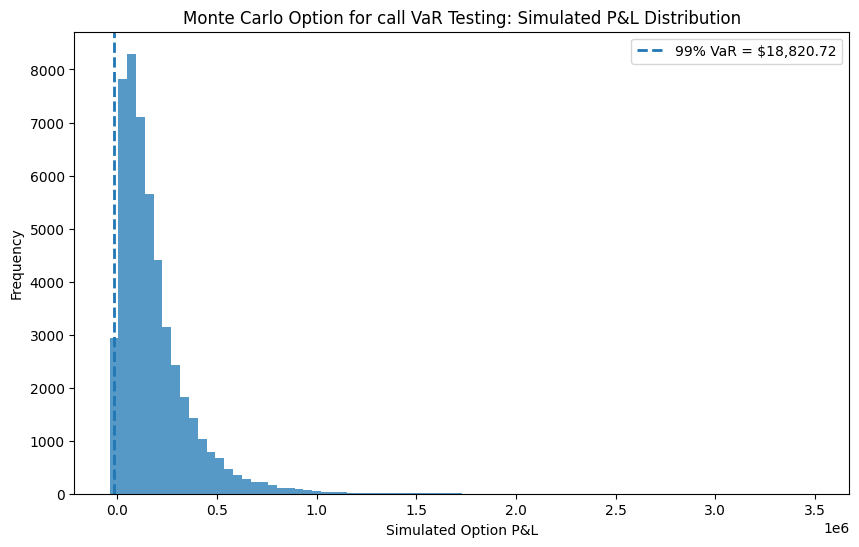

In [ ]:
import matplotlib.pyplot as plt
pnl = result["pnl"]
var = result["var"]

plt.figure(figsize=(10, 6))
plt.hist(pnl, bins=80, alpha=0.75)

# VaR line
plt.axvline(-var, linestyle="--", linewidth=2, label=f"99% VaR = ${var:,.2f}")
plt.title("Monte Carlo Option for call VaR Testing: Simulated P&L Distribution")
plt.xlabel("Simulated Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [2]:
import sys
print(sys.executable)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python


"Put option"

In [ ]:
import pandas as pd
import numpy as np

# Select ATM put
closest_idx = (puts["strike"] - S0).abs().idxmin()
option = puts.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# Correct time to maturity
expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

T = max((expiration_date - today).days / 365, 1 / 365)

# Horizon cannot exceed remaining maturity
horizon_days = min(1, max((expiration_date - today).days, 1))
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=T,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="put",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=horizon_days
)
raw_var = result["var"]
clean_var = max(raw_var, 0)

print("Selected Put:")
print(option)

print("T:", T)
print("Horizon days:", horizon_days)
print("Monte Carlo Put VaR:", clean_var)
print("1% PnL percentile:", np.percentile(result["pnl"], 1))

Selected Put:
contractSymbol             AAPL260511P00292500
lastTradeDate        2026-05-08 19:59:57+00:00
strike                                   292.5
lastPrice                                 1.54
bid                                       1.45
ask                                        1.6
change                                   -4.89
percentChange                        -76.04977
volume                                  7218.0
openInterest                               425
impliedVolatility                     0.319831
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Name: 29, dtype: object
T: 0.00821917808219178
Horizon days: 1
Monte Carlo Put VaR: 1522.2154169396852
1% PnL percentile: -1522.2154169396852


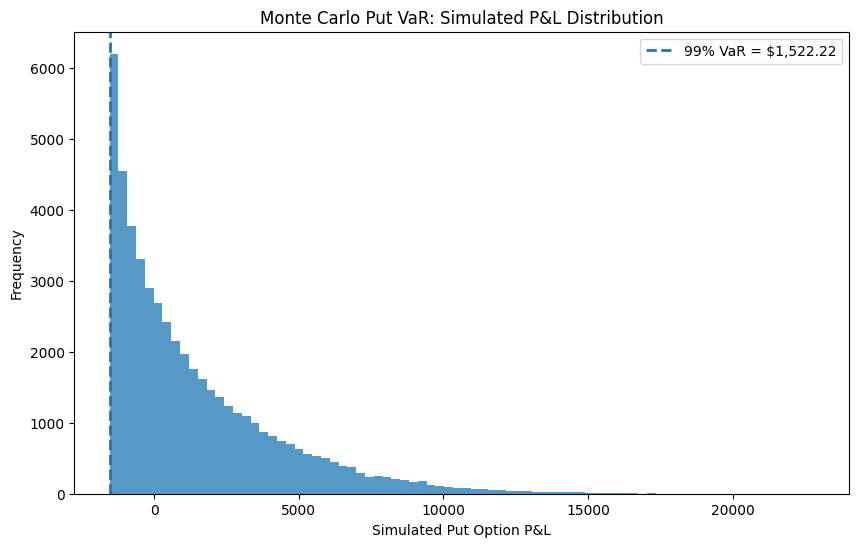

In [18]:
import matplotlib.pyplot as plt
import numpy as np

pnl = result["pnl"]
var = clean_var

plt.figure(figsize=(10, 6))

plt.hist(pnl, bins=80, alpha=0.75)

plt.axvline(
    -var,
    linestyle="--",
    linewidth=2,
    label=f"99% VaR = ${var:,.2f}"
)

plt.title("Monte Carlo Put VaR: Simulated P&L Distribution")
plt.xlabel("Simulated Put Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [19]:
print(exp)

2026-05-11


  Expiration_Type Expiration_Date  Strike  Option_Price  Implied_Vol  \
0           Short      2026-05-11   292.5          1.54     0.319831   
1          Medium      2026-05-20   290.0          3.10     0.252205   
2            Long      2026-07-17   295.0         11.93     0.220436   

          T           VaR  
0  0.008219   1540.000000  
1  0.032877   3100.000000  
2  0.191781  10517.243231  


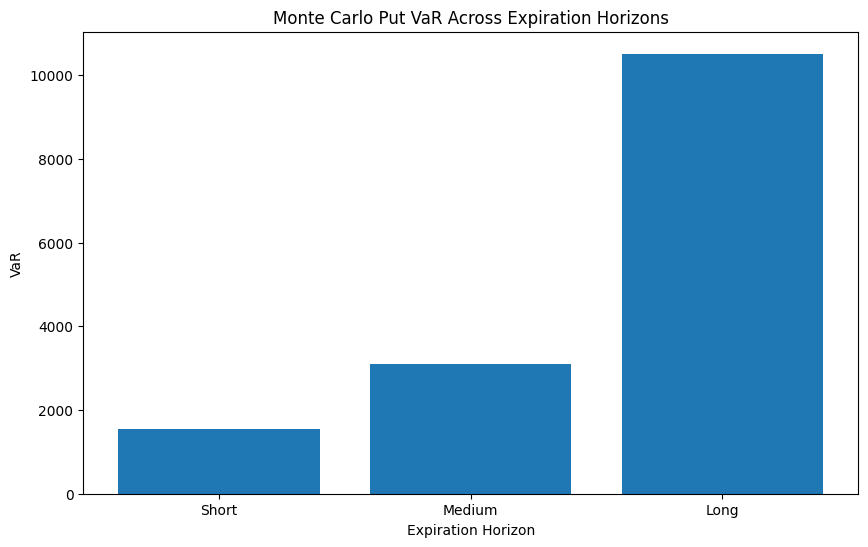

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk.monte_carlo_var import monte_carlo_option_var

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# Current stock price
stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

contracts = 10

# ---------------------------------------------
# Expiration selections
# ---------------------------------------------

expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []

# ---------------------------------------------
# Run Monte Carlo VaR for each expiration
# ---------------------------------------------

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)
    puts = chain.puts

    # Select ATM put
    closest_idx = (puts["strike"] - S0).abs().idxmin()
    option = puts.loc[closest_idx]

    K = option["strike"]
    option_price = option["lastPrice"]
    sigma = option["impliedVolatility"]

    # Time to maturity
    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    T = max((expiration_date - today).days / 365, 1 / 365)

    horizon_days = min(10, max((expiration_date - today).days, 1))

    # Monte Carlo VaR
    result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=0.05,
        sigma=sigma,
        option_price=option_price,
        option_type="put",
        contracts=contracts,
        n_sim=50000,
        confidence=0.99,
        horizon_days=horizon_days
    )

    var = max(result["var"], 0)

    results.append({
        "Expiration_Type": label,
        "Expiration_Date": exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Vol": sigma,
        "T": T,
        "VaR": var
    })

# ---------------------------------------------
# Results table
# ---------------------------------------------

df_results = pd.DataFrame(results)

print(df_results)

# ---------------------------------------------
# Visualization
# ---------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    df_results["Expiration_Type"],
    df_results["VaR"]
)

plt.title("Monte Carlo Put VaR Across Expiration Horizons")
plt.xlabel("Expiration Horizon")
plt.ylabel("VaR")

plt.show()

Available expirations:
('2026-05-11', '2026-05-13', '2026-05-15', '2026-05-18', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')
  Expiration_Type Expiration_Date  Days_to_Expiration  Strike  Option_Price  \
0           Short      2026-05-11                   3   292.5          1.54   
1          Medium      2026-05-20                  12   290.0          3.10   
2            Long      2026-07-17                  70   295.0         11.93   

   Implied_Vol  Portfolio_Value  Horizon_Days           VaR     VaR_%  
0     0.319831           1540.0             3   1540.000000  1.000000  
1     0.252205           3100.0            10   3100.000000  1.000000  
2     0.220436          11930.0            10  10517.243231  0.881579  


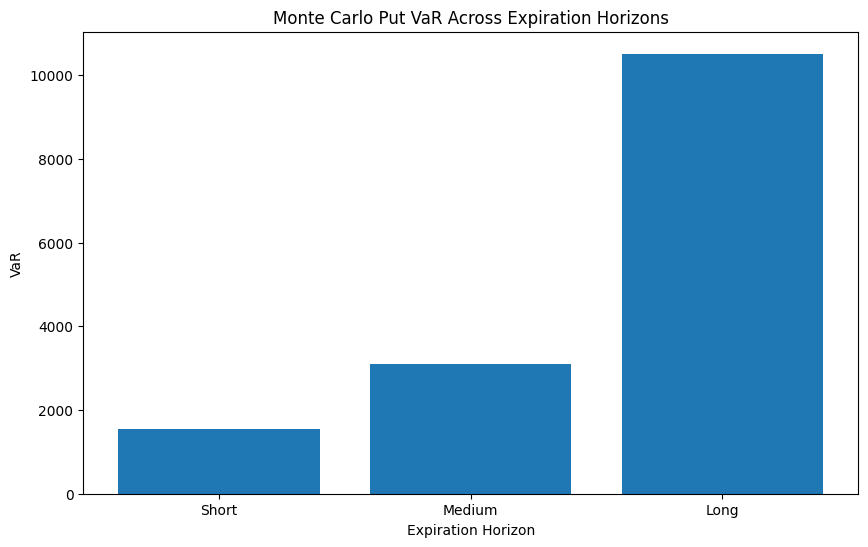

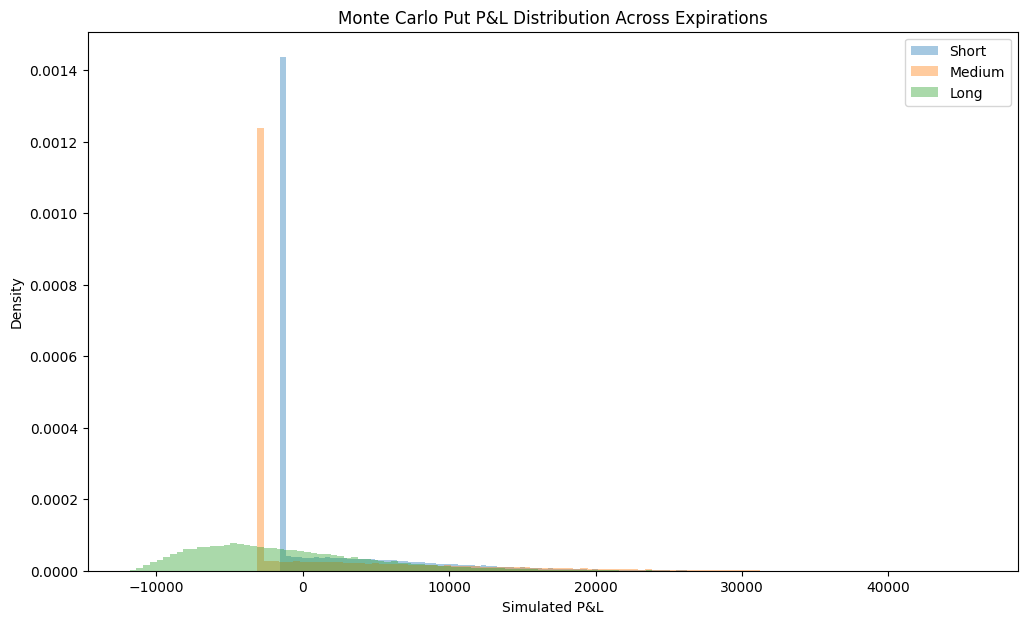

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.risk.monte_carlo_var import monte_carlo_option_var

ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

stock_hist = ticker.history(period="5d")
S0 = stock_hist["Close"].iloc[-1]

contracts = 10
r = 0.05
confidence = 0.99

print("Available expirations:")
print(ticker.options)

expirations = {
    "Short": ticker.options[0],
    "Medium": ticker.options[4],
    "Long": ticker.options[10]
}

results = []
all_pnls = {}

for label, exp in expirations.items():

    chain = ticker.option_chain(exp)
    puts = chain.puts

    # Select ATM put
    closest_idx = (puts["strike"] - S0).abs().idxmin()
    option = puts.loc[closest_idx]

    K = option["strike"]
    option_price = option["lastPrice"]
    sigma = option["impliedVolatility"]

    expiration_date = pd.to_datetime(exp).tz_localize(None)
    today = stock_hist.index[-1].tz_localize(None)

    days_to_exp = max((expiration_date - today).days, 1)
    T = days_to_exp / 365

    horizon_days = min(10, days_to_exp)

    result = monte_carlo_option_var(
        S0=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma,
        option_price=option_price,
        option_type="put",
        contracts=contracts,
        n_sim=50000,
        confidence=confidence,
        horizon_days=horizon_days
    )
    
    var = max(result["var"], 0)
    portfolio_value = option_price * 100 * contracts

    results.append({
        "Expiration_Type": label,
        "Expiration_Date": exp,
        "Days_to_Expiration": days_to_exp,
        "Strike": K,
        "Option_Price": option_price,
        "Implied_Vol": sigma,
        "Portfolio_Value": portfolio_value,
        "Horizon_Days": horizon_days,
        "VaR": var,
        "VaR_%": var / portfolio_value if portfolio_value > 0 else np.nan
    })

    all_pnls[label] = result["pnl"]

df_results = pd.DataFrame(results)

print(df_results)

# Bar chart: VaR by expiration
plt.figure(figsize=(10, 6))
plt.bar(df_results["Expiration_Type"], df_results["VaR"])
plt.title("Monte Carlo Put VaR Across Expiration Horizons")
plt.xlabel("Expiration Horizon")
plt.ylabel("VaR")
plt.show()

# Histogram: P&L distribution by expiration
plt.figure(figsize=(12, 7))

for label, pnl in all_pnls.items():
    plt.hist(pnl, bins=100, alpha=0.4, density=True, label=label)

plt.title("Monte Carlo Put P&L Distribution Across Expirations")
plt.xlabel("Simulated P&L")
plt.ylabel("Density")
plt.legend()
plt.show()